# Microsoft Stock Data Analysis

**Assignment 4 — NumPy review, loading Microsoft financial data, and visualizing it with Matplotlib.**

This notebook follows `TODO.txt` step by step:

1. Review Chapter 2 of the NumPy book (arrays, indexing, vectorized operations).
2. Load Microsoft data and convert the values and dates into NumPy arrays.
3. Plot the data two ways with Matplotlib — together on a single graph and split across separate sub-charts.

**Data source:** `2026-q1.csv` — Microsoft Corporation, **2026 Q1** (the original 2023 sample range has been adjusted to this modern quarter).

## Step 1 — NumPy Chapter 2 Review

Chapter 2 of the NumPy book reviews the fundamentals we used last week and adds a few new ideas:

- **Creating arrays:** `np.array()`, `np.arange()`, `np.zeros()`, `np.ones()`.
- **Array attributes:** `.shape`, `.ndim`, `.dtype`, `.size`.
- **Indexing & slicing:** `a[0]`, `a[:5]`, and boolean masks such as `a[a > 0]`.
- **Vectorized operations:** arithmetic is applied element-wise without explicit loops.
- **Converting tabular data:** pandas Series/DataFrames expose `.to_numpy()`, which hands us a plain NumPy array for analysis.

We apply these ideas below when we convert the Microsoft data into NumPy arrays.

### Imports

We need NumPy for array math, pandas to read the CSV, and Matplotlib for plotting. (`yfinance` was used in the original snippet's download step, but it has been replaced by the local CSV below so the notebook runs offline.)

In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.3
Pandas version: 3.0.6


## Step 2 — Load the Microsoft data

The original TODO downloaded 2023 data with `yfinance` and pulled the `Adj Close` column. That date range has been **adjusted to the modern quarter (2026 Q1)**, and the data now comes from the local `2026-q1.csv` file.

As in the snippet, we convert the numeric column and the dates into NumPy arrays and print the first five items of each.

In [6]:
# Define the ticker and load the local quarterly dataset
ticker = 'MSFT'

# Original download step (replaced by the local CSV so it runs offline):
# df = yf.download(ticker, start='2023-01-01', end='2024-01-01')

df = pd.read_csv('2026-q1.csv')

# Convert the numeric 'value' column to a NumPy array for analysis
time_series_data = df['value'].to_numpy()

# Convert the 'period_end' column to a NumPy array of dates
time_series_dates = pd.to_datetime(df['period_end']).to_numpy()

# Keep the metric labels around for plotting
metrics = df['metric'].to_numpy()

# Display the data
print(f"NumPy time series for {ticker}:\n")
print("Dates (first 5):\n", time_series_dates[:5])
print("\nValues (first 5):\n", time_series_data[:5])
print("\nMetrics:\n", metrics)

NumPy time series for MSFT:

Dates (first 5):
 ['2026-03-31T00:00:00.000000' '2026-03-31T00:00:00.000000'
 '2026-03-31T00:00:00.000000' '2026-03-31T00:00:00.000000'
 '2026-03-31T00:00:00.000000']

Values (first 5):
 [8.2886000e+10 4.2700000e+00 1.5803000e+10 6.7630000e+01 1.9065946e+01]

Metrics:
 ['revenue' 'eps' 'free-cash-flow' 'gross-margin' 'fcf-margin' 'pe-ratio']


In [7]:
# Preview the full table pulled from the CSV
df[['company', 'quarter', 'period_end', 'metric', 'value', 'display']]

,company,quarter,period_end,metric,value,display
0,Microsoft Corporation,2026 Q1,2026-03-31,revenue,8.288600e+10,$82.89B
1,Microsoft Corporation,2026 Q1,2026-03-31,eps,4.270000e+00,$4.27
2,Microsoft Corporation,2026 Q1,2026-03-31,free-cash-flow,1.580300e+10,$15.80B
3,Microsoft Corporation,2026 Q1,2026-03-31,gross-margin,6.763000e+01,67.6%
4,Microsoft Corporation,2026 Q1,2026-03-31,fcf-margin,1.906595e+01,19.1%
5,Microsoft Corporation,2026 Q1,2026-03-31,pe-ratio,2.203000e+01,22.0


## Step 3 — Visualize the data two ways

Matplotlib is used to plot the data in two different ways:

1. **Together on a single graph** — all metrics shown on one figure.
2. **Split across separate sub-charts** — one chart per metric.

Because the metrics span very different scales (billions of dollars vs. single digits), the combined chart uses a logarithmic y-axis so every bar stays visible.

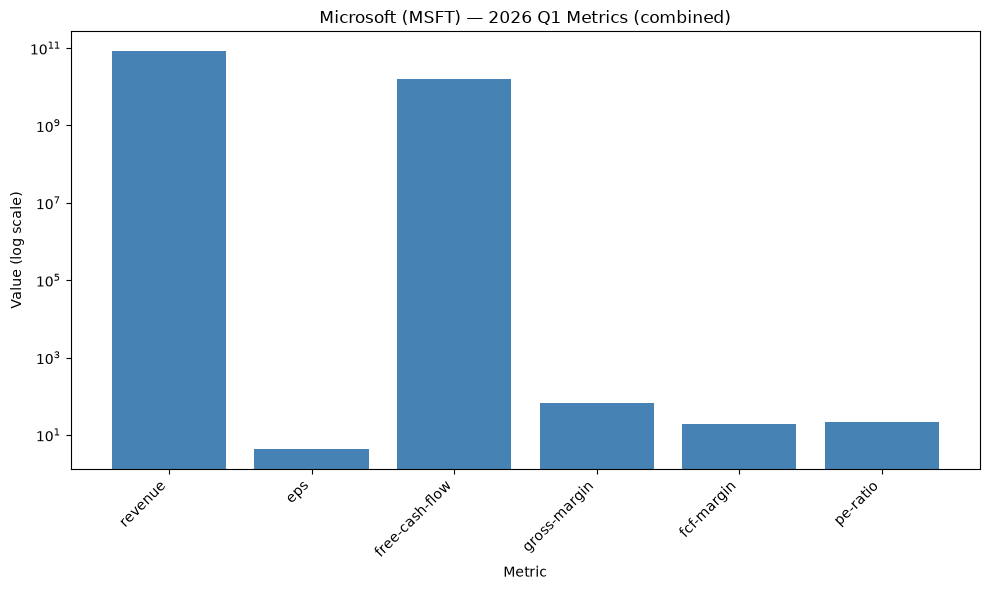

In [8]:
# --- Plot 1: everything together on a single graph ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(metrics, time_series_data, color='steelblue')

# Metrics have very different magnitudes, so use a log scale
ax.set_yscale('log')
ax.set_title('Microsoft (MSFT) — 2026 Q1 Metrics (combined)')
ax.set_xlabel('Metric')
ax.set_ylabel('Value (log scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

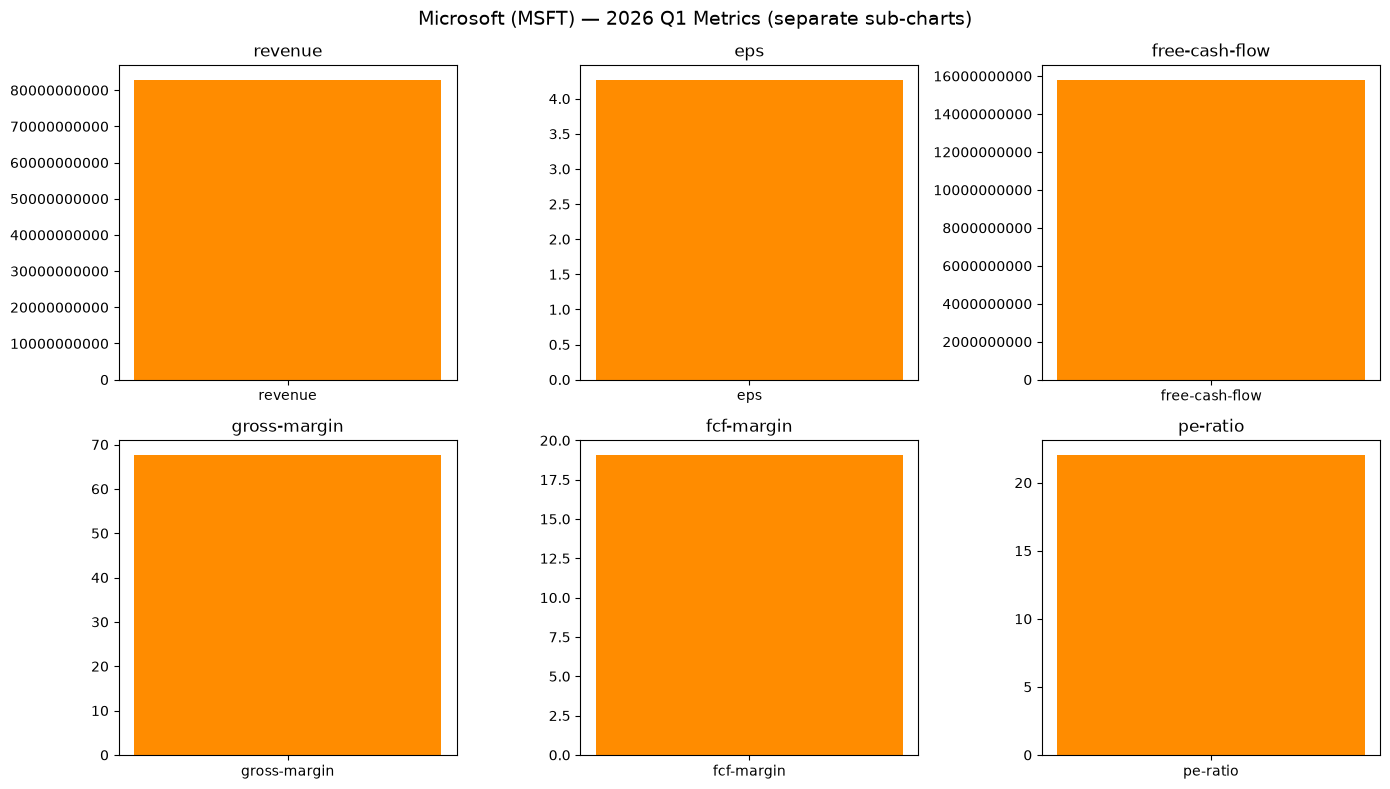

In [9]:
# --- Plot 2: split across separate sub-charts (one per metric) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    axes[i].bar(metric, time_series_data[i], color='darkorange')
    axes[i].set_title(metric)
    axes[i].ticklabel_format(axis='y', style='plain')

fig.suptitle('Microsoft (MSFT) — 2026 Q1 Metrics (separate sub-charts)', fontsize=14)
plt.tight_layout()
plt.show()

### Summary

- NumPy arrays were created from the Microsoft data using `.to_numpy()`.
- The dataset was adjusted to the **modern quarter (2026 Q1)** and read from `2026-q1.csv`.
- The metrics were plotted **together on a single graph** and **split across separate sub-charts** using Matplotlib.